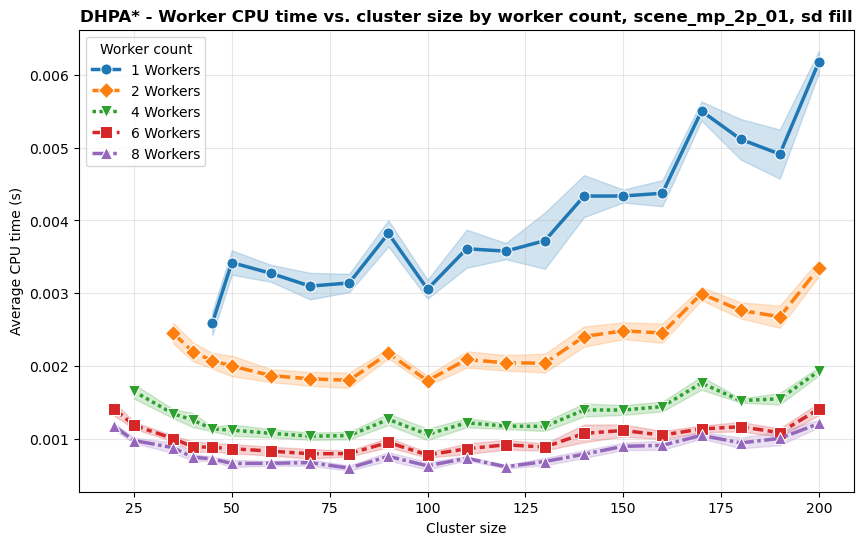

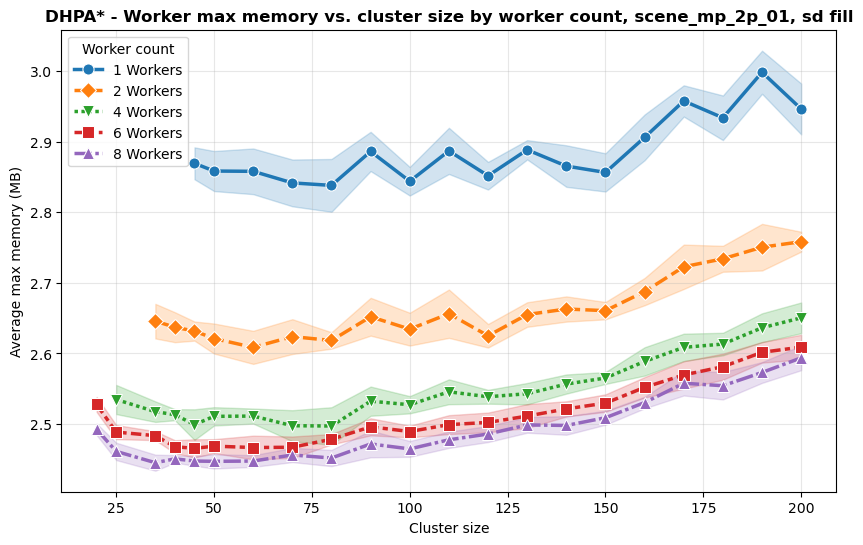

In [14]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    res = json.load(f)

# Parse raw run entries into a pandas DataFrame
records = []
for entry in res['data']:
    c_size = entry['cluster_size']
    w_size = entry['workers_size']
    timings = entry['timings']
    worker_analysis = timings.get('worker_analysis', {})
    
    cpu_times = [v for k, v in worker_analysis.items() if k.endswith('_cpu_time')]
    mem_usages = [v for k, v in worker_analysis.items() if k.endswith('_max_memory_mb')]
    
    if cpu_times and mem_usages:
        records.append({
            'cluster_size': c_size,
            'workers_size': w_size,
            'avg_worker_cpu_time_s': np.mean(cpu_times),
            'max_worker_mem_mb': np.max(mem_usages)
        })

df = pd.DataFrame(records)

# Filter out individual runs where values equal 0
df_cpu = df[df['avg_worker_cpu_time_s'] != 0].copy()
df_mem = df[df['max_worker_mem_mb'] != 0].copy()

# Cast workers_size to string for distinct tab10 color mapping
df_cpu['workers_size'] = df_cpu['workers_size'].astype(str) + " Workers"
df_mem['workers_size'] = df_mem['workers_size'].astype(str) + " Workers"

# Figure 1: Worker CPU Time vs Cluster Size with SD fill
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_cpu, 
    x="cluster_size", 
    y="avg_worker_cpu_time_s", 
    hue="workers_size",
    style="workers_size",                  
    markers=['o', 'D', 'v', 's', '^'], 
    markersize=8,                          
    palette="tab10", 
    linewidth=2.5,
    errorbar='sd',  # <--- Automatically computes and adds the standard deviation fill
    ax=ax1
)
ax1.set_title('DHPA* - Worker CPU time vs. cluster size by worker count, scene_mp_2p_01, sd fill', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cluster size')
ax1.set_ylabel('Average CPU time (s)')
ax1.legend(title="Worker count")
ax1.grid(True, alpha=0.3)
plt.show()

# Figure 2: Max Worker Memory vs Cluster Size with SD fill
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_mem, 
    x="cluster_size", 
    y="max_worker_mem_mb", 
    hue="workers_size",
    style="workers_size",                  
    markers=['o', 'D', 'v', 's', '^'], 
    markersize=8,                          
    palette="tab10", 
    linewidth=2.5,
    errorbar='sd',  # <--- Automatically computes and adds the standard deviation fill
    ax=ax2
)
ax2.set_title('DHPA* - Worker max memory vs. cluster size by worker count, scene_mp_2p_01, sd fill', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster size')
ax2.set_ylabel('Average max memory (MB)')
ax2.legend(title="Worker count")
ax2.grid(True, alpha=0.3)
plt.show()

NameError: name 'workers_sizes' is not defined

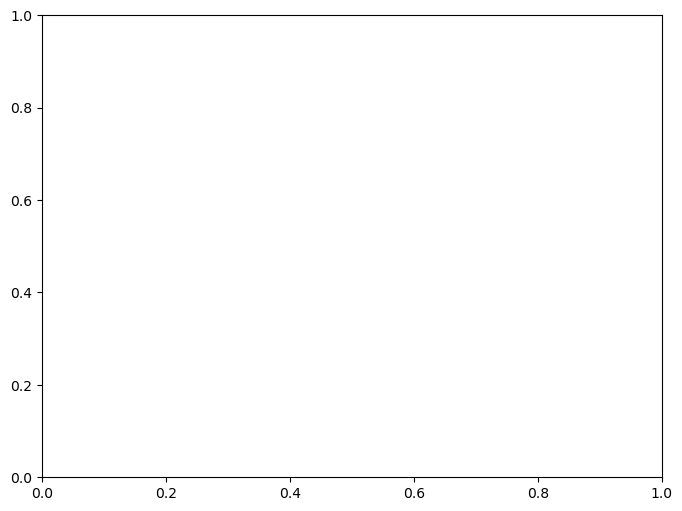

In [ ]:
# Figure 2: Max Worker Memory vs Cluster Size (values equal to 0 removed)
fig2, ax2 = plt.subplots(figsize=(8, 6))
for i, w in enumerate(workers_sizes):
    sub = agg[agg['workers_size'] == w]
    sub_mem = sub[sub['max_mem'] != 0]  # Filter out 0 values
    ax2.plot(sub_mem['cluster_size'], sub_mem['max_mem'], marker='s', color=colors[i], label=f'{w} Workers')

ax2.set_title('Max Worker Memory Usage vs. Cluster Size')
ax2.set_xlabel('Cluster Size')
ax2.set_ylabel('Max Worker Memory (MB)')
ax.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

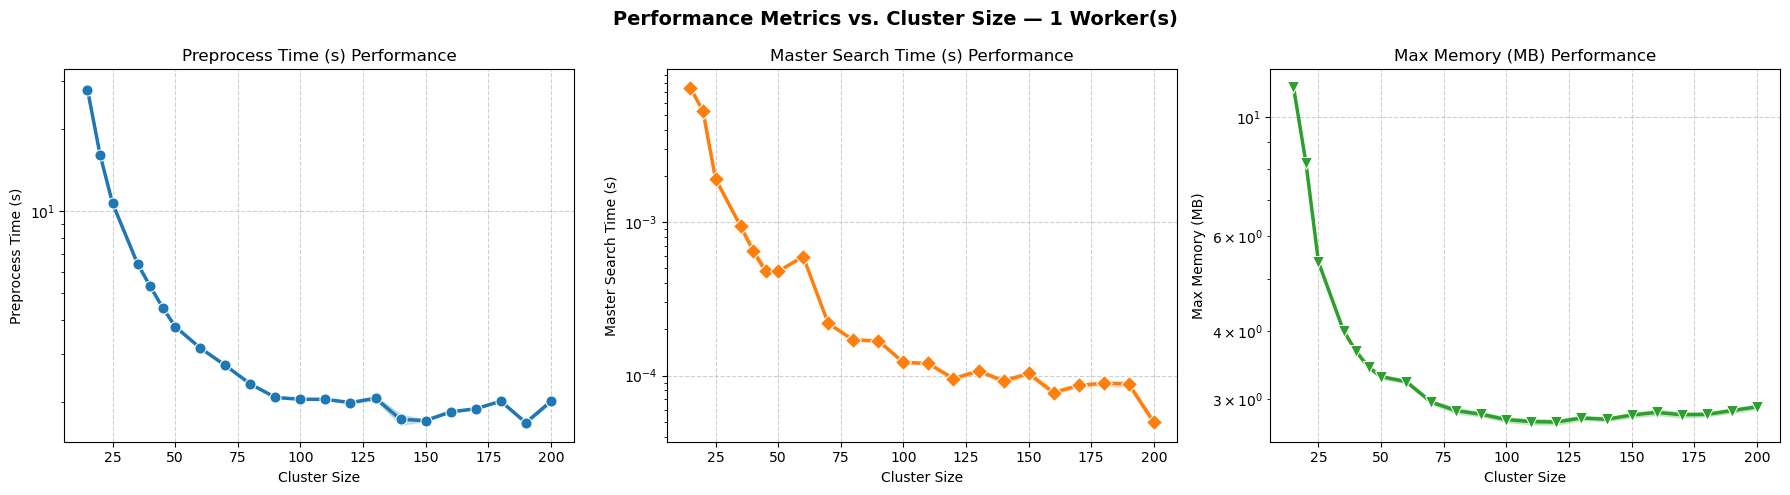

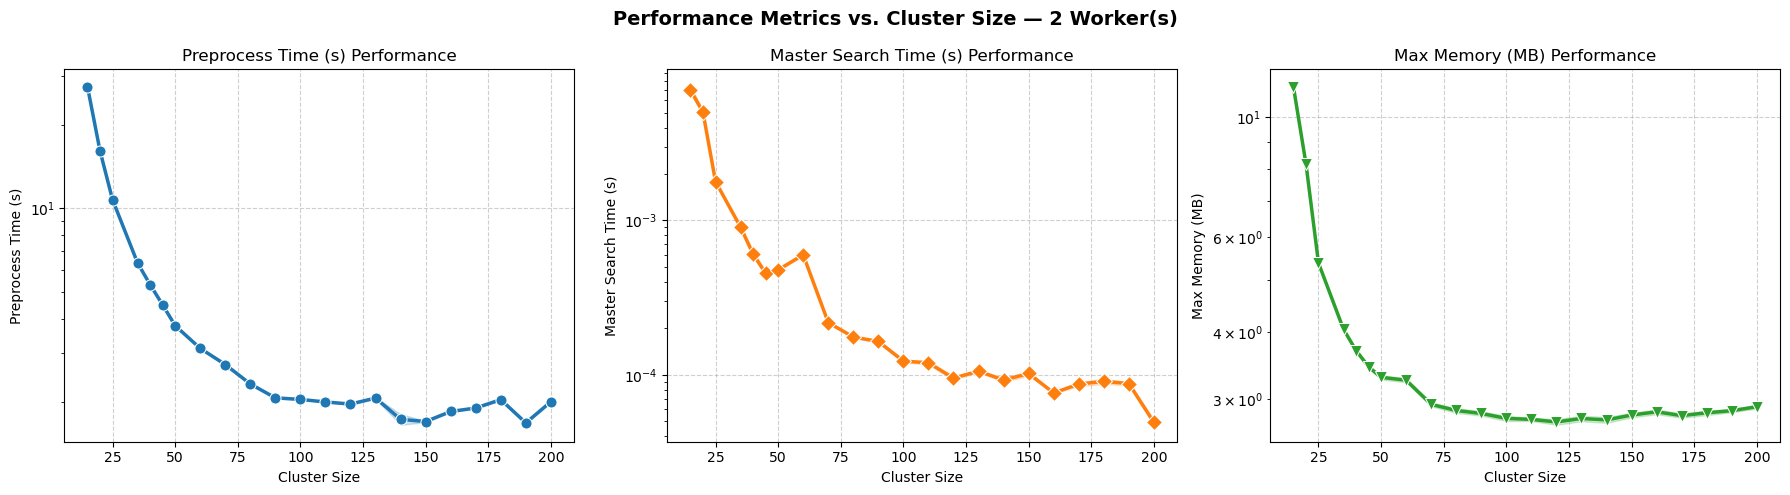

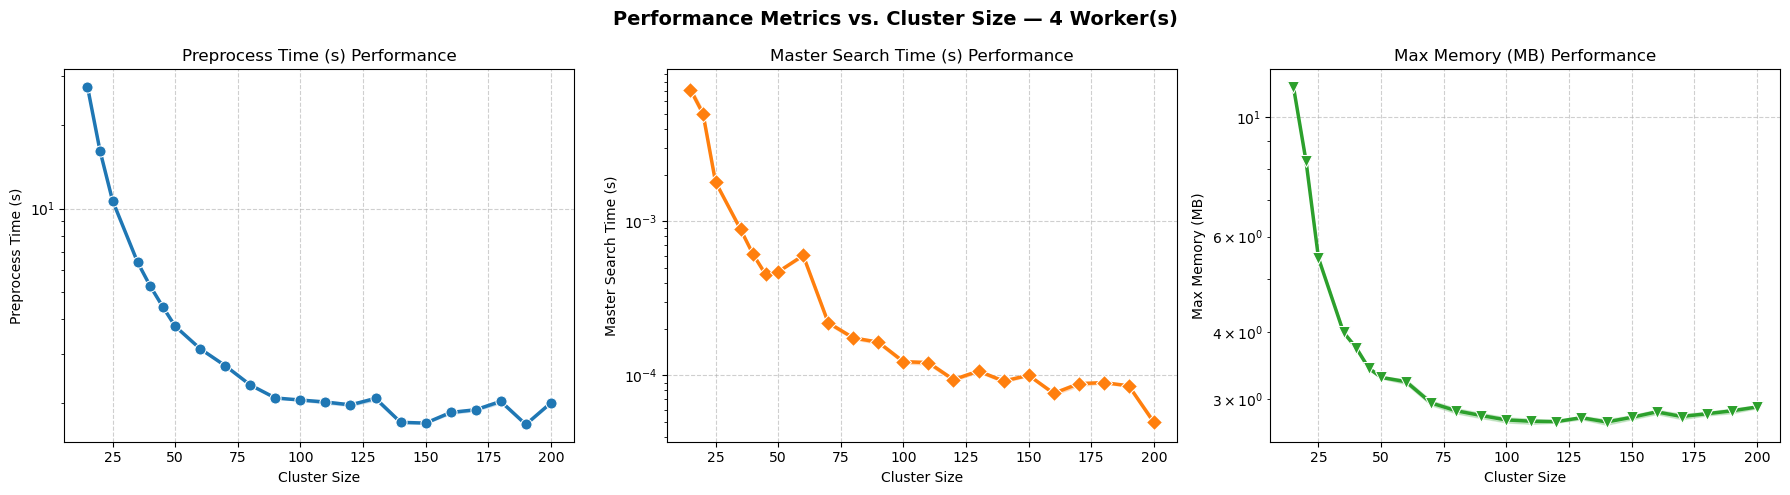

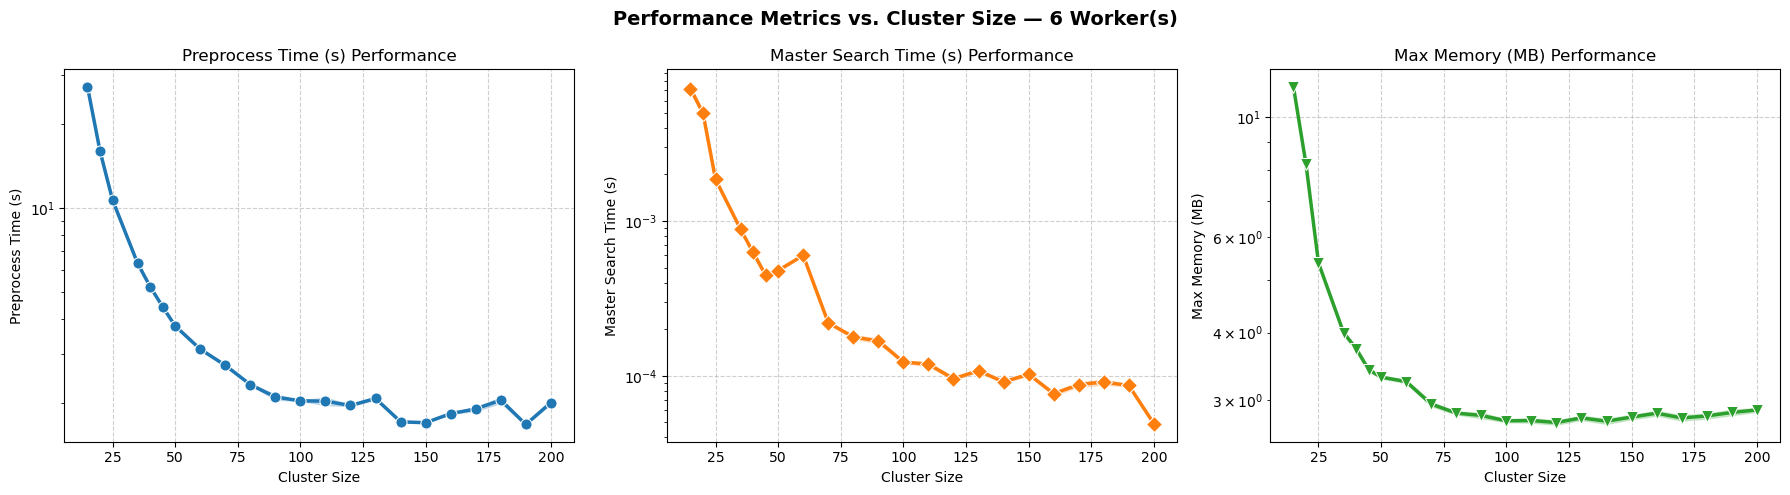

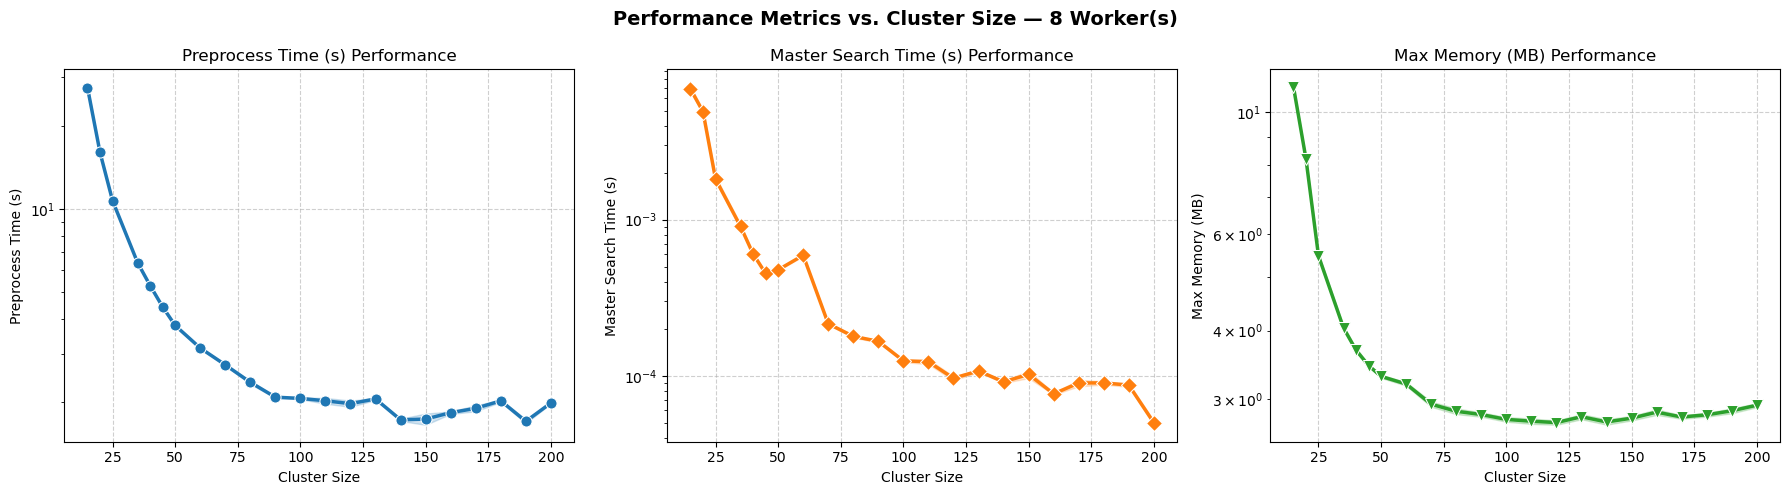

In [10]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    res = json.load(f)

# 2. Parse raw run entries into a clean DataFrame
records = []
for entry in res['data']:
    c_size = entry['cluster_size']
    w_size = entry['workers_size']
    timings = entry['timings']
    
    records.append({
        'cluster_size': c_size,
        'workers_size': w_size,
        'preprocess_time_s': timings.get('preprocessed', 0),
        'master_search_time_s': timings.get('found_graph_path', 0),
        'max_memory_mb': timings.get('max_memory', 0)
    })

df = pd.DataFrame(records)

# Unique worker counts to iterate through (1, 2, 4, 6, 8)
worker_counts = sorted(df['workers_size'].unique())

# Define styling elements to match your template
markers = ['o', 'D', 'v']
metrics = ['preprocess_time_s', 'master_search_time_s', 'max_memory_mb']
labels = ['Preprocess Time (s)', 'Master Search Time (s)', 'Max Memory (MB)']

# 3. Generate 5 separate graphs (one for each worker pool size)
for workers in worker_counts:
    # Filter dataset for the current worker group
    df_worker = df[df['workers_size'] == workers].copy()
    
    # Initialize figure with 3 subplots side-by-side to track all 3 metrics clearly
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Performance Metrics vs. Cluster Size — {workers} Worker(s)', fontsize=14, fontweight='bold')
    
    for i, metric in enumerate(metrics):
        sns.lineplot(
            data=df_worker,
            x="cluster_size",
            y=metric,
            marker=markers[i],
            markersize=8,
            linewidth=2.5,
            color=plt.cm.tab10(i), # Keeps color profiles consistent across graphs
            errorbar='sd',          # Automatically computes standard deviation fill
            ax=axes[i]
        )
        
        # Labels & Polish
        axes[i].set_title(f'{labels[i]} Performance')
        axes[i].set_xlabel('Cluster Size')
        axes[i].set_ylabel(labels[i])
        axes[i].set_yscale('log')
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

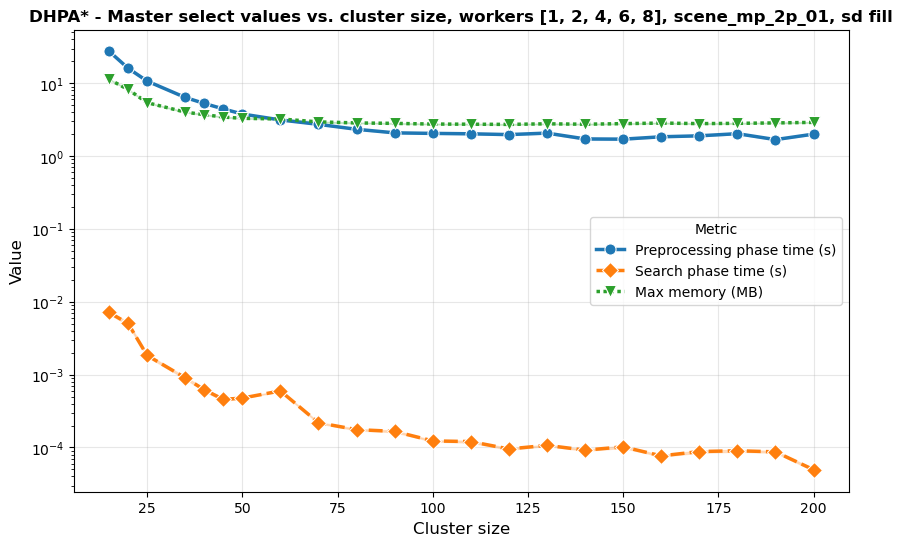

In [16]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    res = json.load(f)

# 2. Parse raw run entries into a clean DataFrame
records = []
for entry in res['data']:
    c_size = entry['cluster_size']
    w_size = entry['workers_size']
    timings = entry['timings']
    
    records.append({
        'cluster_size': c_size,
        'preprocess_time_s': timings.get('preprocessed', 0),
        'master_search_time_s': timings.get('found_graph_path', 0),
        'max_memory_mb': timings.get('max_memory', 0)
    })

df = pd.DataFrame(records)

# 3. Melt the DataFrame to long-form for seaborn hue/style mapping
df_melted = df.melt(
    id_vars=['cluster_size'],
    value_vars=['preprocess_time_s', 'master_search_time_s', 'max_memory_mb'],
    var_name='Metric',
    value_name='Value'
)

# Rename metrics for professional display
metric_labels = {
    'preprocess_time_s': 'Preprocessing phase time (s)',
    'master_search_time_s': 'Search phase time (s)',
    'max_memory_mb': 'Max memory (MB)'
}
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

# 4. Generate the single combined plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df_melted,
    x="cluster_size",
    y="Value",
    hue="Metric",
    style="Metric",
    markers=['o', 'D', 'v'],
    markersize=8,
    palette="tab10",
    linewidth=2.5,
    errorbar='sd',  # Automatically computes SD across all worker counts & runs combined
    ax=ax
)

# Apply logarithmic scale to Y-axis
ax.set_yscale('log')

# Title, Labels, and Formatting
ax.set_title('DHPA* - Master select values vs. cluster size, workers [1, 2, 4, 6, 8], scene_mp_2p_01, sd fill', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster size', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()